# Chess Elo Prediction with XGBoost
Predicts player Elo ratings from in-game behavior features extracted from PGN files.

In [2]:
%pip install python-chess xgboost scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import chess.pgn
import chess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

## Step 1: Feature Extraction
For each game, we count behavioral stats per player: captures, checks, castling, promotions, piece diversity, and timing of key events.

In [4]:
def extract_features(game):
    board = game.board()

    white_moves = []
    black_moves = []

    white_captures     = 0
    black_captures     = 0
    white_checks       = 0
    black_checks       = 0
    white_castled      = False
    black_castled      = False
    white_promotions   = 0
    black_promotions   = 0

    white_piece_diversity = set()
    black_piece_diversity = set()

    white_move_numbers = []   # track which move numbers white played (for avg game length proxy)
    black_move_numbers = []

    move_number = 0
    for move in game.mainline_moves():
        san = board.san(move)
        is_white = board.turn

        piece = board.piece_at(move.from_square)
        piece_type = piece.piece_type if piece else 0

        if is_white:
            white_moves.append(san)
            white_piece_diversity.add(piece_type)
            white_move_numbers.append(move_number)
            if board.is_capture(move):              white_captures += 1
            if move.promotion:                      white_promotions += 1
            if san.endswith("+") or san.endswith("#"): white_checks += 1
            if san in ("O-O", "O-O-O"):             white_castled = True
        else:
            black_moves.append(san)
            black_piece_diversity.add(piece_type)
            black_move_numbers.append(move_number)
            if board.is_capture(move):              black_captures += 1
            if move.promotion:                      black_promotions += 1
            if san.endswith("+") or san.endswith("#"): black_checks += 1
            if san in ("O-O", "O-O-O"):             black_castled = True

        board.push(move)
        move_number += 1

    total_moves  = move_number
    white_count  = len(white_moves)
    black_count  = len(black_moves)

    # On which move did castling happen? Earlier = more principled opening play
    white_castle_move = next(
        (white_move_numbers[i] for i, m in enumerate(white_moves) if m in ("O-O", "O-O-O")),
        total_moves  # default: never castled = late / end of game
    )
    black_castle_move = next(
        (black_move_numbers[i] for i, m in enumerate(black_moves) if m in ("O-O", "O-O-O")),
        total_moves
    )

    return {
        # --- game-level ---
        "total_moves":              total_moves,
        "result":                   game.headers.get("Result", "*"),

        # --- white features ---
        "white_move_count":         white_count,
        "white_captures":           white_captures,
        "white_checks":             white_checks,
        "white_castled":            int(white_castled),
        "white_castle_move":        white_castle_move,
        "white_promotions":         white_promotions,
        "white_piece_diversity":    len(white_piece_diversity),
        "white_capture_rate":       white_captures / white_count if white_count else 0,
        "white_check_rate":         white_checks   / white_count if white_count else 0,
        "white_avg_move_number":    np.mean(white_move_numbers) if white_move_numbers else 0,

        # --- black features ---
        "black_move_count":         black_count,
        "black_captures":           black_captures,
        "black_checks":             black_checks,
        "black_castled":            int(black_castled),
        "black_castle_move":        black_castle_move,
        "black_promotions":         black_promotions,
        "black_piece_diversity":    len(black_piece_diversity),
        "black_capture_rate":       black_captures / black_count if black_count else 0,
        "black_check_rate":         black_checks   / black_count if black_count else 0,
        "black_avg_move_number":    np.mean(black_move_numbers) if black_move_numbers else 0,

        # --- targets ---
        "WhiteElo":                 int(game.headers.get("WhiteElo", 0)),
        "BlackElo":                 int(game.headers.get("BlackElo", 0)),
    }

## Step 2: Load PGN File

In [5]:
pgn_path = r"C:\Users\Admin\source\Phyton\ARJK\data.pgn"  # <-- update this path

rows = []
with open(pgn_path, encoding="utf-8") as pgn:
    while True:
        game = chess.pgn.read_game(pgn)
        if game is None:
            break
        rows.append(extract_features(game))

df = pd.DataFrame(rows)
print(f"Total games loaded: {len(df)}")
df.head(5)

Total games loaded: 50000


,total_moves,result,white_move_count,white_captures,white_checks,white_castled,white_castle_move,white_promotions,white_piece_diversity,white_capture_rate,...,black_checks,black_castled,black_castle_move,black_promotions,black_piece_diversity,black_capture_rate,black_check_rate,black_avg_move_number,WhiteElo,BlackElo
0,38,1/2-1/2,19,4,1,1,12,0,6,0.210526,...,0,1,9,0,6,0.263158,0.000000,19.0,2354,2411
1,13,1/2-1/2,7,1,0,1,12,0,4,0.142857,...,0,0,13,0,2,0.166667,0.000000,6.0,2523,2460
2,106,0-1,53,11,4,1,14,0,6,0.207547,...,5,1,13,0,6,0.226415,0.094340,53.0,1915,1999
3,77,1-0,39,8,4,0,77,0,6,0.205128,...,1,1,13,0,6,0.236842,0.026316,38.0,2446,2191
4,49,1-0,25,8,4,1,14,0,5,0.320000,...,0,0,49,0,6,0.208333,0.000000,24.0,2168,2075


## Step 3: Clean & Prepare Data

In [6]:
# Drop games with missing or unrated Elo
df = df[(df["WhiteElo"] > 0) & (df["BlackElo"] > 0)].copy()

# Drop outlier Elos — unrated players often default to 1500 or get weird values
df = df[(df["WhiteElo"] >= 600) & (df["WhiteElo"] <= 2800)]
df = df[(df["BlackElo"] >= 600) & (df["BlackElo"] <= 2800)]

# Encode result
result_map = {"1-0": 1, "0-1": 0, "1/2-1/2": 0.5}
df["result_encoded"] = df["result"].map(result_map).fillna(0.5)
df.drop(columns=["result"], inplace=True)

print(f"Games after cleaning: {len(df)}")
print("\nElo distribution:")
print(df[["WhiteElo", "BlackElo"]].describe())

Games after cleaning: 24941

Elo distribution:
           WhiteElo      BlackElo
count  24941.000000  24941.000000
mean    2245.642516   2240.633295
std      267.521536    270.017834
min     1021.000000   1128.000000
25%     2074.000000   2067.000000
50%     2271.000000   2266.000000
75%     2446.000000   2446.000000
max     2797.000000   2793.000000


## Step 4: Visualize Elo Distribution
If this looks weird (spike at 1500, very skewed), your data has unrated players — filter further.

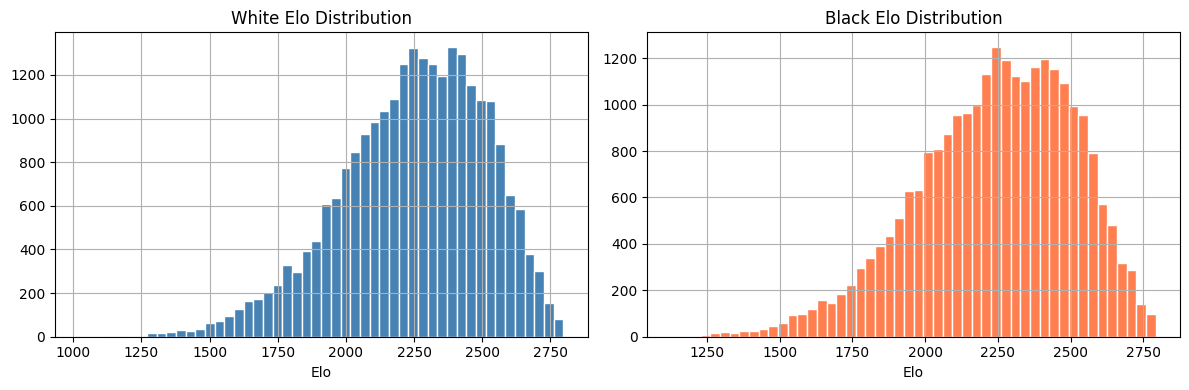

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["WhiteElo"].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("White Elo Distribution")
axes[0].set_xlabel("Elo")

df["BlackElo"].hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Black Elo Distribution")
axes[1].set_xlabel("Elo")

plt.tight_layout()
plt.show()

## Step 5: Define Features & Split Data
Two separate models — one for white, one for black. Each uses that player's own stats as primary input, plus opponent stats as context.

In [8]:
white_features = [
    "total_moves", "result_encoded",
    "white_move_count", "white_captures", "white_checks",
    "white_castled", "white_castle_move", "white_promotions",
    "white_piece_diversity", "white_capture_rate", "white_check_rate",
    "white_avg_move_number",
    # opponent context
    "black_move_count", "black_captures", "black_checks",
    "black_castled", "black_castle_move", "black_piece_diversity",
]

black_features = [
    "total_moves", "result_encoded",
    "black_move_count", "black_captures", "black_checks",
    "black_castled", "black_castle_move", "black_promotions",
    "black_piece_diversity", "black_capture_rate", "black_check_rate",
    "black_avg_move_number",
    # opponent context
    "white_move_count", "white_captures", "white_checks",
    "white_castled", "white_castle_move", "white_piece_diversity",
]

X_white = df[white_features]
X_black = df[black_features]
y_white = df["WhiteElo"]
y_black = df["BlackElo"]

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42
)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_black, y_black, test_size=0.2, random_state=42
)

print(f"Training samples: {len(Xw_train)}")
print(f"Test samples:     {len(Xw_test)}")

Training samples: 19952
Test samples:     4989


## Step 6: Train XGBoost Models

In [9]:
model_white = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,   # use 80% of features per tree (reduces overfitting)
    min_child_weight=10,    # min samples in a leaf node
    random_state=42,
    verbosity=0             # suppress XGBoost logs
)

model_black = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    random_state=42,
    verbosity=0
)

print("Training white model...")
model_white.fit(Xw_train, yw_train)

print("Training black model...")
model_black.fit(Xb_train, yb_train)

print("Done.")

Training white model...
Training black model...
Done.


## Step 7: Evaluate

In [10]:
yw_pred = model_white.predict(Xw_test)
yb_pred = model_black.predict(Xb_test)

print("=== White Elo ===")
print(f"  MAE:  {mean_absolute_error(yw_test, yw_pred):.1f}")
print(f"  RMSE: {np.sqrt(np.mean((yw_test - yw_pred)**2)):.1f}")
print(f"  R²:   {r2_score(yw_test, yw_pred):.4f}")

print("\n=== Black Elo ===")
print(f"  MAE:  {mean_absolute_error(yb_test, yb_pred):.1f}")
print(f"  RMSE: {np.sqrt(np.mean((yb_test - yb_pred)**2)):.1f}")
print(f"  R²:   {r2_score(yb_test, yb_pred):.4f}")

=== White Elo ===
  MAE:  202.5
  RMSE: 256.1
  R²:   0.0788

=== Black Elo ===
  MAE:  206.6
  RMSE: 257.1
  R²:   0.0815


## Step 8: Sample Predictions

In [11]:
print("White — Predicted:", yw_pred[:5].round(0))
print("White — Actual:   ", yw_test.values[:5])

print("\nBlack — Predicted:", yb_pred[:5].round(0))
print("Black — Actual:   ", yb_test.values[:5])

White — Predicted: [2184. 2251. 2265. 2341. 2294.]
White — Actual:    [1991 2124 2471 2123 2593]

Black — Predicted: [2322. 2113. 2148. 2165. 2322.]
Black — Actual:    [2280 1746 2087 1944 2590]


## Step 9: Feature Importance

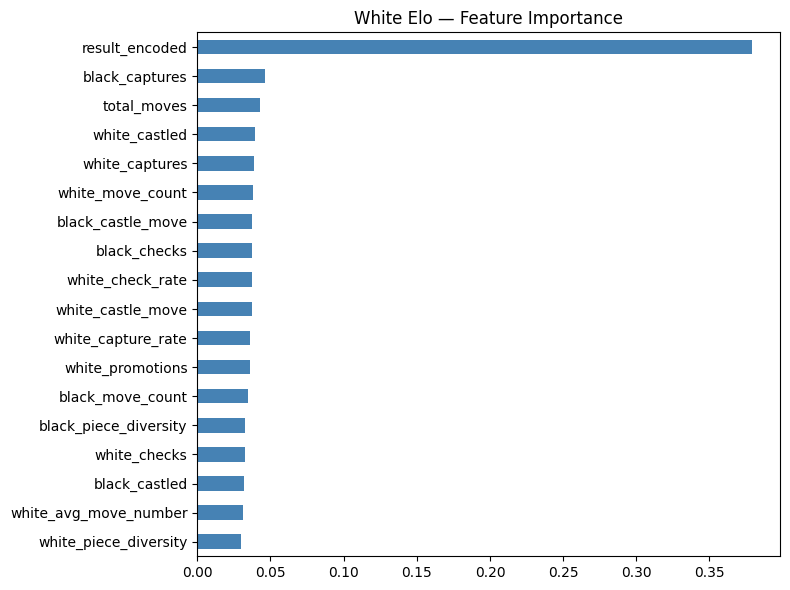

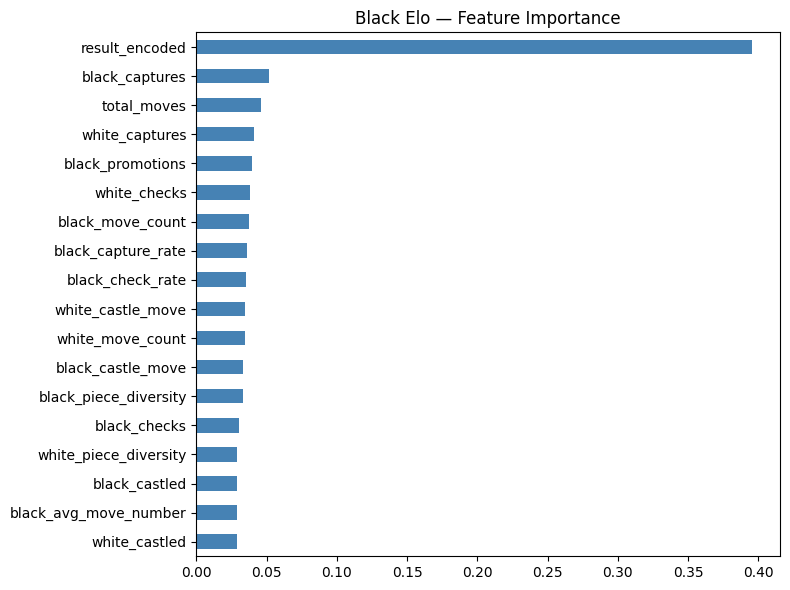

In [12]:
for label, model, features in [
    ("White", model_white, white_features),
    ("Black", model_black, black_features),
]:
    importance = pd.Series(model.feature_importances_, index=features)
    importance.sort_values().plot(
        kind="barh", figsize=(8, 6),
        title=f"{label} Elo — Feature Importance",
        color="steelblue"
    )
    plt.tight_layout()
    plt.show()

## Step 10: Actual vs Predicted Plot
A well-fitting model should cluster tightly around the diagonal.

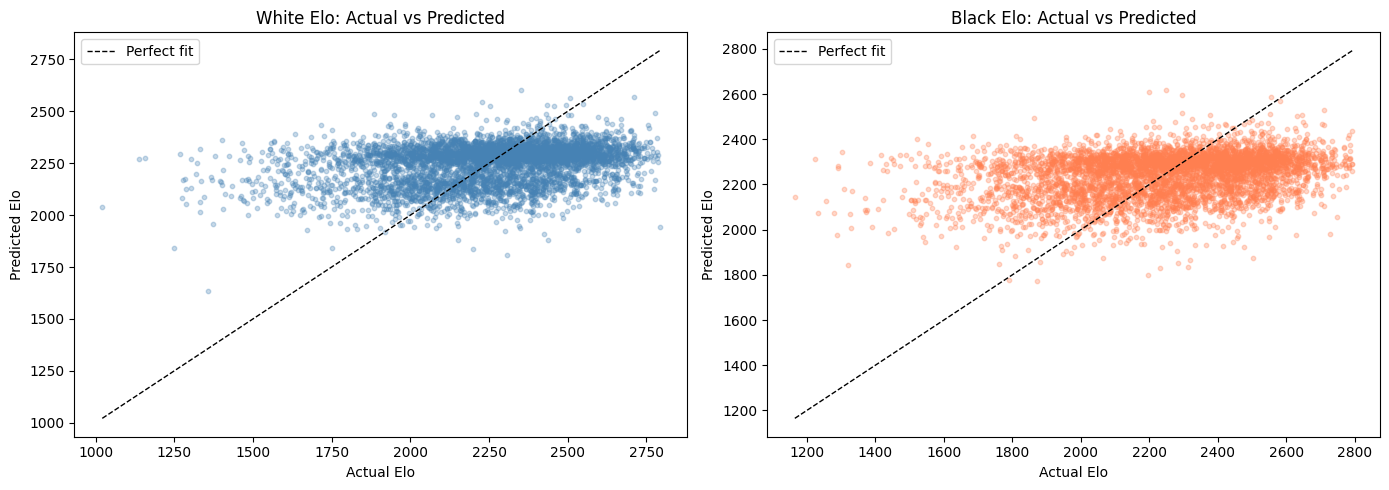

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, actual, predicted, label, color in [
    (axes[0], yw_test, yw_pred, "White", "steelblue"),
    (axes[1], yb_test, yb_pred, "Black", "coral"),
]:
    ax.scatter(actual, predicted, alpha=0.3, s=10, color=color)
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='Perfect fit')
    ax.set_xlabel("Actual Elo")
    ax.set_ylabel("Predicted Elo")
    ax.set_title(f"{label} Elo: Actual vs Predicted")
    ax.legend()

plt.tight_layout()
plt.show()